In [66]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(42)
n = 3000

# Features
age = rng.normal(55, 12, n).clip(18, 90)
bmi = rng.normal(28, 5, n)
family_history = rng.binomial(1, 0.25, n)
smoker = rng.binomial(1, 0.18, n)

# True disease mechanism
logit = (
    -2.0
    + 0.03 * (age - 55)
    + 0.05 * (bmi - 28)
    + 1.0 * family_history
    + 0.8 * smoker
)

p_true = 1 / (1 + np.exp(-logit))
disease = rng.binomial(1, p_true)

print("Prevalence:", disease.mean())

# Train a model to generate realistic scores
X = pd.DataFrame(
    {
        "age": age,
        "bmi": bmi,
        "family_history": family_history,
        "smoker": smoker,
    }
)

model = LogisticRegression(max_iter=1000)
model.fit(X, disease)

p_model = model.predict_proba(X)[:, 1]

# Deliberately overconfident
def make_overconfident(p, alpha=2):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    odds = p / (1 - p)
    odds = odds**alpha
    return odds / (1 + odds)

predicted_risk = make_overconfident(p_model, alpha=2.3)

df = X.copy()
df["predicted_risk"] = predicted_risk
df["disease"] = disease

Path("../data").mkdir(exist_ok=True)
df.to_csv("../data/rural_screening.csv", index=False)

print(df["predicted_risk"].describe())

Prevalence: 0.18133333333333335
count    3000.000000
mean        0.069772
std         0.134907
min         0.000220
25%         0.005455
50%         0.014596
75%         0.065096
max         0.958868
Name: predicted_risk, dtype: float64


count    3.000000e+03
mean     2.503290e-01
std      3.907338e-01
min      9.644810e-17
25%      5.820943e-06
50%      2.403257e-03
75%      4.457063e-01
max      1.000000e+00
Name: predicted_risk, dtype: float64


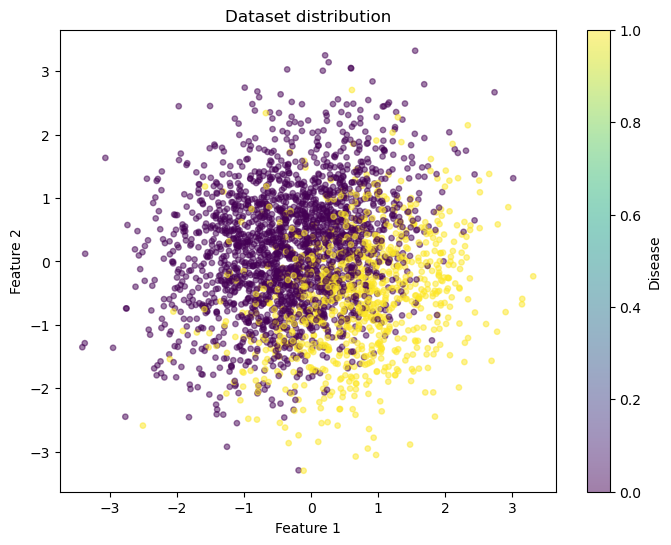

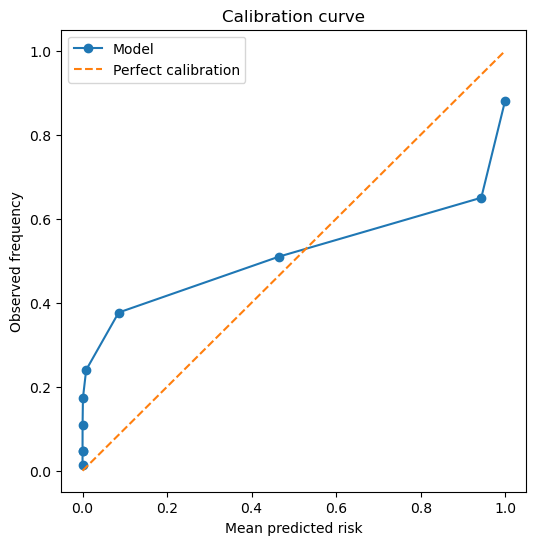

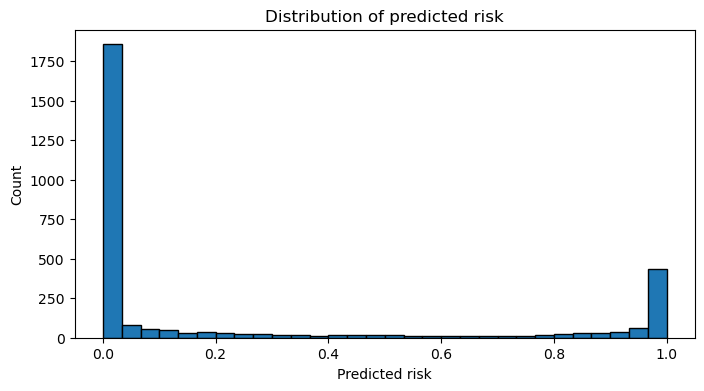

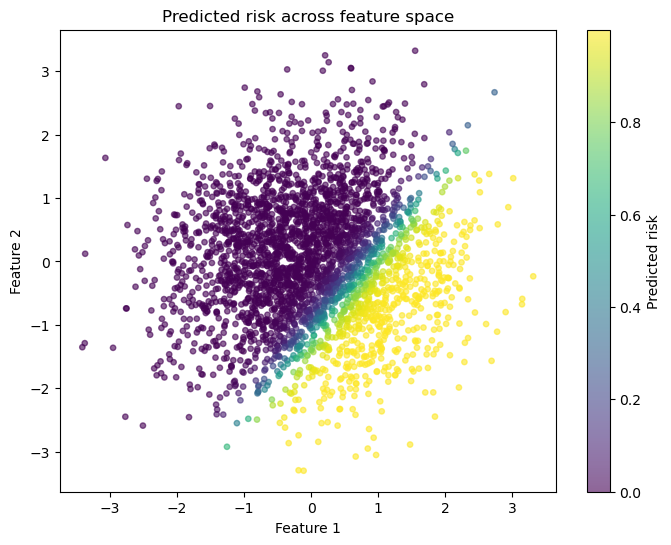

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(43)
n = 3000

# Two anonymous numerical features
feature_1 = rng.normal(0, 1, n)
feature_2 = rng.normal(0, 1, n)

# True disease mechanism: mostly linear, so score keeps useful information
logit_true = (
    -1.4
    + 1.6 * feature_1
    - 1.2 * feature_2
)

p_true = 1 / (1 + np.exp(-logit_true))
disease = rng.binomial(1, p_true)

X = pd.DataFrame(
    {
        "feature 1": feature_1,
        "feature 2": feature_2,
    }
)

# Train a model that learns the right ranking
model = LogisticRegression(max_iter=1000)
model.fit(X, disease)

p_model = model.predict_proba(X)[:, 1]

# Deliberately make it poorly calibrated
# alpha > 1 makes the model overconfident
def make_overconfident(p, alpha=3.0):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    odds = p / (1 - p)
    odds = odds**alpha
    return odds / (1 + odds)

predicted_risk = make_overconfident(p_model, alpha=4.5)

df = X.copy()
df["predicted_risk"] = predicted_risk
df["disease"] = disease

Path("../data").mkdir(exist_ok=True)
df.to_csv("../data/rural_screening.csv", index=False)

print(df["predicted_risk"].describe())


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["feature 1"],
    df["feature 2"],
    c=df["disease"],
    alpha=0.5,
    s=15,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset distribution")
plt.colorbar(label="Disease")
plt.show()


from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    df["disease"],
    df["predicted_risk"],
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")

plt.xlabel("Mean predicted risk")
plt.ylabel("Observed frequency")
plt.title("Calibration curve")
plt.legend()
plt.show()


plt.figure(figsize=(8, 4))

plt.hist(
    df["predicted_risk"],
    bins=30,
    edgecolor="black",
)

plt.xlabel("Predicted risk")
plt.ylabel("Count")
plt.title("Distribution of predicted risk")
plt.show()


plt.figure(figsize=(8, 6))

plt.scatter(
    df["feature 1"],
    df["feature 2"],
    c=df["predicted_risk"],
    cmap="viridis",
    alpha=0.6,
    s=15,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Predicted risk across feature space")
plt.colorbar(label="Predicted risk")
plt.show()